In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_glass_data

df = load_glass_data(target="Tg")
print(f"Shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")

Shape: (49972, 23)

Features: ['SiO2', 'P2O5', 'ZrO2', 'Na2O', 'Al2O3', 'CaO', 'MgO', 'K2O', 'B2O3', 'BaO', 'ZnO', 'Li2O', 'SrO', 'La2O3', 'TiO2', 'Nb2O5', 'PbO', 'WO3', 'Sb2O3', 'Bi2O3', 'TeO2', 'other_compounds', 'Tg']


count    49972.000000
mean       516.209325
std        141.557805
min         65.000000
25%        420.000000
50%        508.000000
75%        605.000000
max       1222.000000
Name: Tg, dtype: float64


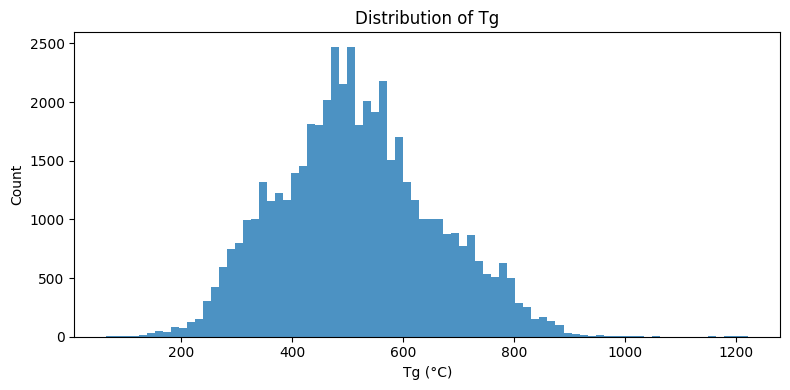

In [2]:
print(df["Tg"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["Tg"], bins=80, edgecolor="none", alpha=0.8)
plt.xlabel("Tg (°C)")
plt.ylabel("Count")
plt.title("Distribution of Tg")
plt.tight_layout()
plt.savefig("../outputs/tg_distribution.png", dpi=150)
plt.show()

count    49972.000000
mean         1.173383
std          2.497375
min          0.000000
25%          0.000000
50%          0.000000
75%          0.554250
max         10.000000
Name: other_compounds, dtype: float64


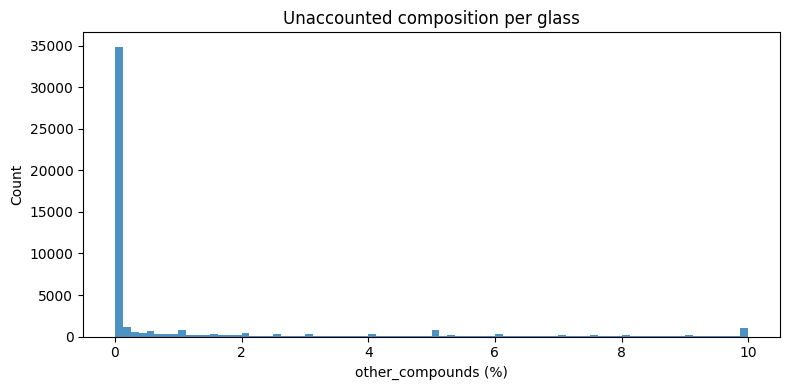

In [3]:
print(df["other_compounds"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["other_compounds"], bins=80, edgecolor="none", alpha=0.8)
plt.xlabel("other_compounds (%)")
plt.ylabel("Count")
plt.title("Unaccounted composition per glass")
plt.tight_layout()
plt.savefig("../outputs/tg_other_compounds.png", dpi=150)
plt.show()

In [4]:
oxide_cols = [c for c in df.columns if c not in ["other_compounds", "Tg"]]

presence = (df[oxide_cols] > 0).mean().sort_values(ascending=False)
mean_when_present = df[oxide_cols].replace(0, float("nan")).mean().sort_values(ascending=False)

summary = pd.DataFrame({
    "presence_%": (presence * 100).round(2),
    "mean_when_present": mean_when_present.round(2),
}).sort_values("presence_%", ascending=False)

print(summary)

       presence_%  mean_when_present
SiO2        60.70              48.90
B2O3        52.32              28.76
Na2O        43.57              14.00
Al2O3       41.47               8.39
CaO         30.20              14.11
Li2O        28.14              15.03
ZnO         27.88              18.10
K2O         25.78               6.78
P2O5        22.83              34.47
BaO         21.90              12.12
MgO         21.84              10.37
TiO2        17.50              10.14
ZrO2        15.36               3.06
La2O3       11.79               9.05
Nb2O5       10.67              10.48
PbO          9.78              29.48
Bi2O3        9.69              22.13
SrO          9.59               8.39
Sb2O3        8.19               4.76
TeO2         8.01              61.85
WO3          7.89              10.71


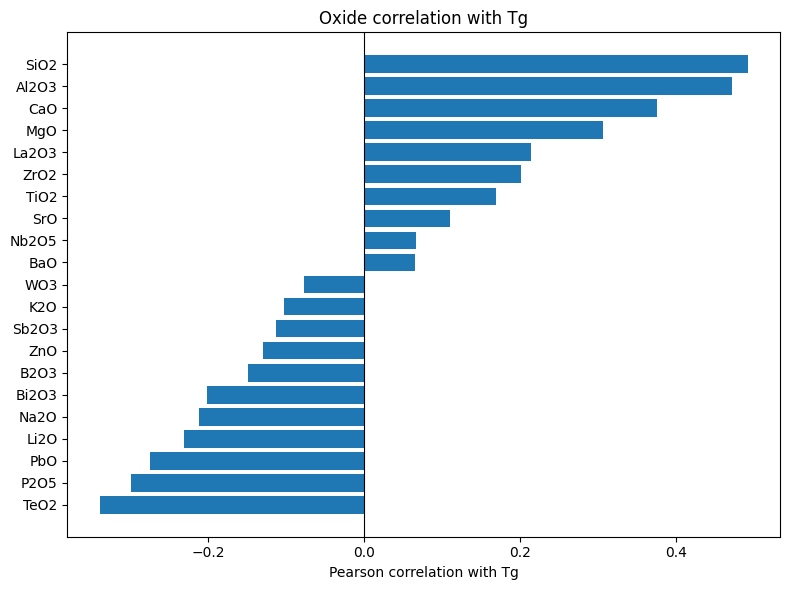

In [9]:
oxide_cols = [c for c in df.columns if c not in ["other_compounds", "Tg"]]

correlations = df[oxide_cols].corrwith(df["Tg"]).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(correlations.index, correlations.values)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with Tg")
plt.title("Oxide correlation with Tg")
plt.tight_layout()
plt.savefig("../outputs/tg_correlations.png", dpi=150)
plt.show()

In [2]:
from glasspy.data import SciGlass

source = SciGlass(
    properties_cfg={"keep_all": True},
    compounds_cfg={"keep_all": True},
)
df_raw = source.data

target_mask = df_raw["property"]["Tg"].notna()
subset = df_raw["compounds"][target_mask]
non_zero_pct = (subset > 0).mean().sort_values(ascending=False)
selected_oxides_5pct = non_zero_pct[non_zero_pct >= 0.05].index.tolist()

print("Oxide presence thresholds:")
print(f"  >5%:  {(non_zero_pct >= 0.05).sum()} oxides")
print(f"  >2%:  {(non_zero_pct >= 0.02).sum()} oxides")
print(f"  >1%:  {(non_zero_pct >= 0.01).sum()} oxides")

print("\nCoverage threshold analysis:")
coverage = subset[selected_oxides_5pct].sum(axis=1)
for thresh in [80, 85, 90, 95]:
    kept = (coverage >= thresh).sum()
    print(f"  >={thresh}%: {kept} rows ({kept/len(subset):.1%})")

Oxide presence thresholds:
  >5%:  24 oxides
  >2%:  40 oxides
  >1%:  62 oxides

Coverage threshold analysis:
  >=80%: 58518 rows (63.8%)
  >=85%: 55460 rows (60.5%)
  >=90%: 52071 rows (56.8%)
  >=95%: 46327 rows (50.5%)


## Key findings

### Dataset
- 49,972 glasses after filtering (90% coverage threshold, 21 oxide features)
- 52,071 rows pass the 90% coverage threshold before the regex oxide filter
- The ~2,000 row difference are glasses where non-oxide compounds (BaF2, Se, Ge)
  were carrying enough composition weight to affect coverage
- 75% of glasses have <0.55% unaccounted composition — the 90% threshold is working well
- Tg range: 65–1222°C, median 508°C

### Oxide composition patterns
- **SiO2 and B2O3** are the most common network formers (60% and 52% presence)
- **TeO2** appears in only 8% of glasses but averages 62% of composition when present — these are tellurite glasses, a distinct family
- **PbO** and **P2O5** similar story — minor presence but high amounts when used (lead and phosphate glass families)
- **ZrO2** used as a minor additive only (~3% average) — not a network former

### Correlations with Tg
- **SiO2, Al2O3, CaO, MgO** positively correlated — network formers/stabilizers that increase Tg
- **TeO2, PbO, P2O5, Na2O, Li2O** negatively correlated — tellurite/lead/phosphate families have lower Tg, alkali oxides break up the glass network
- Correlations reflect glass family differences as much as individual oxide effects — the dataset mixes silicate, borate, tellurite, phosphate, and lead glass families

### Data pipeline decisions

**Oxide selection (5% presence threshold)**
- Going to 2% starts pulling in non-oxide chemistry (fluorides, elements, sulfides)
- 5% keeps the feature set cleanly in oxide territory
- Even at 5%, non-oxides slipped through (BaF2, Se, Ge) because a small subset
  of non-oxide glasses happen to have Tg measured — fixed with a regex filter

**Coverage threshold (90%)**
- 85% → 55,460 rows but allows up to 15% unaccounted composition
- 90% → 52,071 rows before regex filter, 49,972 after — sweet spot between data quantity and composition purity
- 95% → 46,327 rows with little gain over 90%
- The remaining unaccounted % (other_compounds) is genuinely unknown —
  could be other oxides, fluorides, or elements

### Glass chemistry context
- **Network formers** (SiO2, Al2O3, B2O3): build the glass network,
  higher content → higher Tg
- **Network modifiers** (Na2O, Li2O, K2O): break up the glass network
  by providing non-bridging oxygens, higher content → lower Tg
- **Tellurite glasses** (high TeO2): inherently low Tg family,
  TeO2 is a conditional glass former
- **Lead glasses** (high PbO): heavy metal oxide, low Tg,
  historically used for crystal glass and radiation shielding
- **Phosphate glasses** (high P2O5): distinct network former,
  generally lower Tg than silicates